# Variance Swap Backtest
In this notebook I analyse the difference 

In [5]:
import matplotlib.pyplot as plt
import pandas as pd   
import yfinance as yf
import numpy as np
import statsmodels.api as sm
import statistics
from arch import arch_model

In [6]:
spx = yf.download("^GSPC", start="1995-01-01", end="2026-08-01")
vix = yf.download("^VIX", start="1995-01-01", end="2026-08-01")

prices_spx = spx["Close"].squeeze()
prices_vix = vix["Close"].squeeze()
window = 21

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


# What Distrubtion Does Vol Follow
You would expect Nasdaq to have a higher mode due to the idea of 'hype', lack of profits, and other factors.

0.1752287913805824


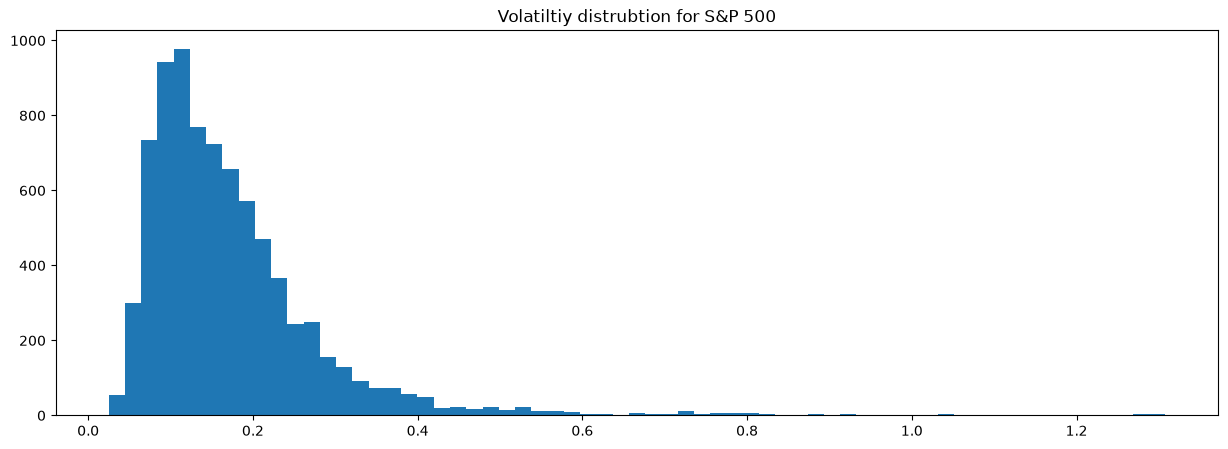

In [21]:
log_return_spx_daily = np.log(prices_spx).diff()
log_return_spx_mean = log_return_spx_daily.mean()
ri_minus_rmean_spx = ((log_return_spx_daily) - log_return_spx_mean ) **2
sum_ri_minus_rmean_spx = (((log_return_spx_daily) - log_return_spx_mean ) **2).rolling(10).sum()
var_spx = (1/(len(log_return_spx_daily) -1) * sum_ri_minus_rmean_spx) * (252/10)
vol_spx = np.sqrt(var_spx) * 100
print(vol_spx.mean())
plt.figure(figsize=(15,5))
plt.hist(vol_spx, bins=65)
plt.title("Volatiltiy distrubtion for S&P 500")

plt.show()

# Modelling future Volatitlity

To make sure the garch model does not learn historical data to fit statistical parameters, I back test it on in and out of sample data in the code below I choose a 70/30 split 

In [35]:
# Use GARCH to forecast variance, I am going to keep everything in variance points for now 
returns_spx = 100 * prices_spx.pct_change().dropna()
split = int(len(returns_spx) * 0.70)
returns_IS_spx = returns_spx.iloc[:split]

In [37]:
model = arch_model(returns_IS_spx, vol='Garch', p=1, q=1, dist='normal')
result = model.fit()
print(result.summary().tables[1])

Iteration:      1,   Func. Count:      6,   Neg. LLF: 10113831861.747005
Iteration:      2,   Func. Count:     15,   Neg. LLF: 2381513758.5216274
Iteration:      3,   Func. Count:     23,   Neg. LLF: 8087.51808908131
Iteration:      4,   Func. Count:     30,   Neg. LLF: 7787.04141422996
Iteration:      5,   Func. Count:     36,   Neg. LLF: 7853.603254736004
Iteration:      6,   Func. Count:     42,   Neg. LLF: 7716.716172006157
Iteration:      7,   Func. Count:     48,   Neg. LLF: 7854.603311490435
Iteration:      8,   Func. Count:     54,   Neg. LLF: 7710.379637737015
Iteration:      9,   Func. Count:     60,   Neg. LLF: 7709.244497542881
Iteration:     10,   Func. Count:     65,   Neg. LLF: 7709.239213012389
Iteration:     11,   Func. Count:     70,   Neg. LLF: 7709.23920869975
Iteration:     12,   Func. Count:     74,   Neg. LLF: 7709.239208699964
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7709.23920869975
            Iterations: 12
   

Now to create a 21 day rolling out of sample backtest 

In [ ]:
model = arch_model(returns_spx, vol='Garch', p=1, q=1, dist='normal')
result = model.fit()
forecast = result.forecast(horizon=21)
daily_var_spx_forecast = forecast.variance.iloc[-1]
var_spx_forecast = (daily_var_spx_forecast.sum())* (1/1000)
print(var_spx_forecast)

In an anthoer notebook I am trying to identify a way to improve volailtity forecasts for nasdaq volatility

# Using the VIX as a proxy for the fair strike and Defining Our VRP

In [23]:

Kvar_spx = ((prices_vix / 100) ** 2 ) **(window / 252)
print(Kvar_spx.mean())

0.7570649288679936


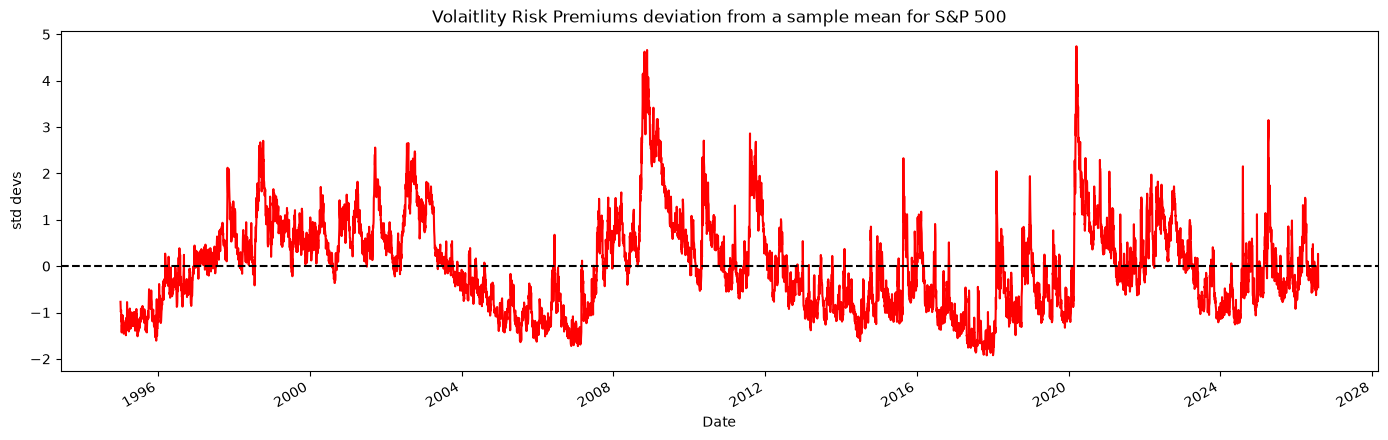

In [24]:
# Now we can define The Volatility Risk Premium
VRP_spx = Kvar_spx - var_spx_forecast
VRP_spx_mean_z_score = ((VRP_spx-VRP_spx.mean())/ VRP_spx.std()).dropna()
VRP_spx_mean_z_score.plot(title='Volaitlity Risk Premiums deviation from a sample mean for S&P 500', ylabel='std devs', color='Red' , figsize=(17,5),)
plt.axhline(0, linestyle = "--", color = 'black')

In [25]:
# Define for a sample mean 
roll_VRP_mean = VRP_spx.expanding(min_periods=252).mean()
roll_VRP_std = VRP_spx.expanding(min_periods=252).std()
VRP_z_score = ((VRP_spx - roll_VRP_mean) / roll_VRP_std).dropna()

In [26]:
VRP_IS_z = VRP_z_score[VRP_z_score.index >= "2011-01-01"]

In [27]:
position = 0
positions = [] #  currenlty have an empty book
entry_req = 1
Days_in_trade = 0
for z in VRP_IS_z:
    enter_position = 0 
    if position == 0:
        if z > entry_req:
            position = -1
            enter_position = -1
            Days_in_trade = 0
            
        elif z < - entry_req:
            position = 1
            entry_today = 1
            Trading_days = 0
    else:
        Days_in_trade += 1
        if Days_in_trade >= 30:
            position = 0 
            trading_days = 0 
    positions.append(enter_position)

print(len(positions))

3918


In [28]:
positions_series = pd.Series(positions, index= VRP_IS_z.index, name="Position")
Record_of_trades = positions_series[positions_series !=0]
print(len(Record_of_trades))

28


In [29]:
realised_var_30d = {}

for date in Record_of_trades.index:
    location = log_return_spx_daily.index.get_loc(date)
    future_returns = log_return_spx_daily.iloc[location + 1 : location + 1 + window]
    if len(future_returns) == window:
        realised_var_30d[date] = ((future_returns ** 2).sum()* (252 / window))
    else:
        realised_var_30d[date] = np.nan

<Axes: title={'center': 'Short Variance swap Returns Out of sample'}, xlabel='Date'>

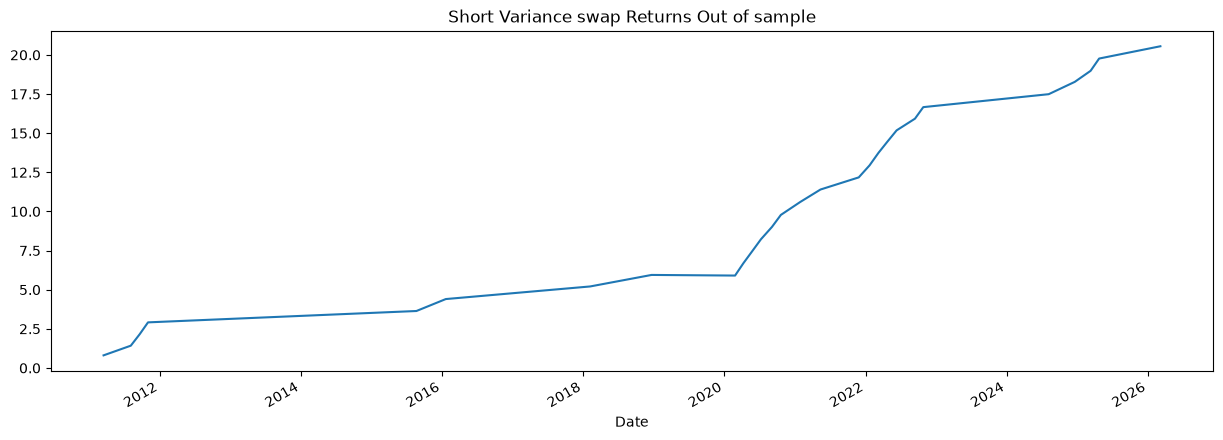

In [32]:
realised_var_30d = pd.Series(realised_var_30d, name="30 day realised variance")

payoff = Record_of_trades * (realised_var_30d - Kvar_spx.loc[Record_of_trades.index])
cumlative_payoff = payoff.cumsum()
cumlative_payoff.plot(title="Short Variance swap Returns Out of sample",figsize=(15,5))


In [31]:
# sharpe 
mean_payoff = payoff.mean()
std_payoff =  payoff.std()
sharpe_per_payoff = mean_payoff / std_payoff
trades_per_year = len(payoff) / (len(VRP_IS_z)/252)
sharpe_annual = (sharpe_per_payoff * np.sqrt(trades_per_year)) 
print(sharpe_annual)

6.240504259799396
